# Statistics Fundamentals for Machine Learning

**Everything you need to become a top ML professional!**

This notebook covers: Mean, Median, Mode, Variance, Standard Deviation, Percentiles, Distributions, Correlation, Z-Scores, and Outlier Detection.

## Contents
1. Central Tendency (Mean, Median, Mode)
2. Measures of Spread (Variance, Std Dev, IQR)
3. Percentiles and Quartiles  
4. Distributions and Skewness
5. Correlation and Covariance
6. Z-Scores and Standardization
7. Outlier Detection
8. ML Applications
9. Practice Exercises

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

sns.set_style('whitegrid')
np.random.seed(42)

## Quick Reference Guide

```
MEASURE          FORMULA                      WHEN TO USE
─────────────────────────────────────────────────────────
Mean             Σx / n                       Symmetric data
Median           Middle value                 Skewed data, outliers
Mode             Most frequent                Categorical data
Variance         Σ(x-μ)² / n                 Understanding spread
Std Dev          √variance                    ⭐ Most important!
IQR              Q3 - Q1                      Robust spread
Correlation      Cov(X,Y)/(σx·σy)            Relationships (-1 to +1)
Z-score          (x-μ)/σ                      Standardization
```

## 1. Central Tendency

### Mean, Median, Mode Explained

Test Scores: [ 45  50  55  60  65  70  75  80  85  90  95 100 100 100]

Mean:   76.43
Median: 77.50
Mode:   100.00


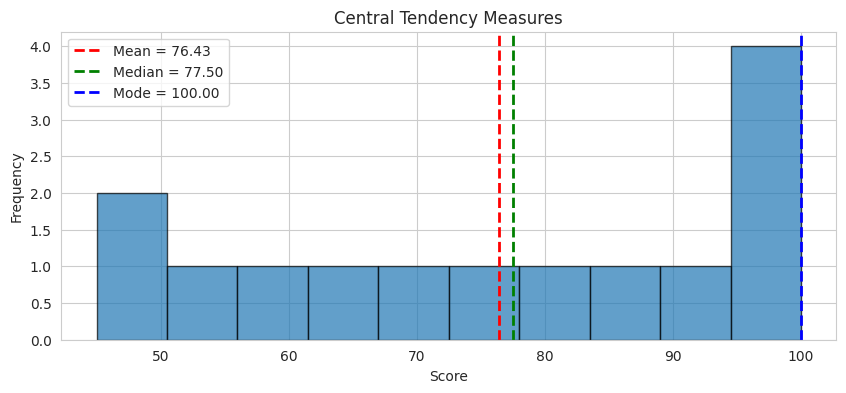

In [8]:
# Example data: test scores
scores = np.array([45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 100, 100])

mean = np.mean(scores)
median = np.median(scores)
mode = stats.mode(scores, keepdims=True).mode[0]

print("Test Scores:", scores)
print(f"\nMean:   {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Mode:   {mode:.2f}")

# Visualize
plt.figure(figsize=(10, 4))
plt.hist(scores, bins=10, edgecolor='black', alpha=0.7)
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean:.2f}')
plt.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median = {median:.2f}')
plt.axvline(mode, color='blue', linestyle='--', linewidth=2, label=f'Mode = {mode:.2f}')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Central Tendency Measures')
plt.legend()
plt.show()

**Effect of Outliers:**

In [9]:
# Salaries without and with CEO
salaries = np.array([40, 45, 50, 55, 60, 65, 70, 75, 80])  # in thousands
salaries_with_outlier = np.array([40, 45, 50, 55, 60, 65, 70, 75, 80, 5000])

print("WITHOUT outlier:")
print(f"  Mean:   ${np.mean(salaries):.1f}k")
print(f"  Median: ${np.median(salaries):.1f}k")

print("\nWITH outlier (CEO):")
print(f"  Mean:   ${np.mean(salaries_with_outlier):.1f}k  ← Jumped!")
print(f"  Median: ${np.median(salaries_with_outlier):.1f}k  ← Stable")

print("\n💡 Use MEDIAN when you have outliers!")

WITHOUT outlier:
  Mean:   $60.0k
  Median: $60.0k

WITH outlier (CEO):
  Mean:   $554.0k  ← Jumped!
  Median: $62.5k  ← Stable

💡 Use MEDIAN when you have outliers!


## 2. Measures of Spread

### Variance and Standard Deviation

In [10]:
# Simple example
data = np.array([2, 4, 4, 4, 5, 5, 7, 9])

print("Data:", data)
print(f"\nStep-by-step calculation:")

# Step 1: Mean
mean = np.mean(data)
print(f"1. Mean = {mean}")

# Step 2: Deviations
deviations = data - mean
print(f"2. Deviations from mean: {deviations}")

# Step 3: Squared deviations
squared_dev = deviations ** 2
print(f"3. Squared deviations: {squared_dev}")

# Step 4: Variance
variance = np.mean(squared_dev)
print(f"4. Variance = {variance:.2f}")

# Step 5: Standard Deviation
std = np.sqrt(variance)
print(f"5. Std Dev = √{variance:.2f} = {std:.2f}")

print(f"\n✅ NumPy results:")
print(f"   Variance: {np.var(data):.2f}")
print(f"   Std Dev:  {np.std(data):.2f}")

print(f"\n💡 Interpretation: Data typically varies by ±{std:.2f} from mean")

Data: [2 4 4 4 5 5 7 9]

Step-by-step calculation:
1. Mean = 5.0
2. Deviations from mean: [-3. -1. -1. -1.  0.  0.  2.  4.]
3. Squared deviations: [ 9.  1.  1.  1.  0.  0.  4. 16.]
4. Variance = 4.00
5. Std Dev = √4.00 = 2.00

✅ NumPy results:
   Variance: 4.00
   Std Dev:  2.00

💡 Interpretation: Data typically varies by ±2.00 from mean


### Comparing Datasets with Different Spreads

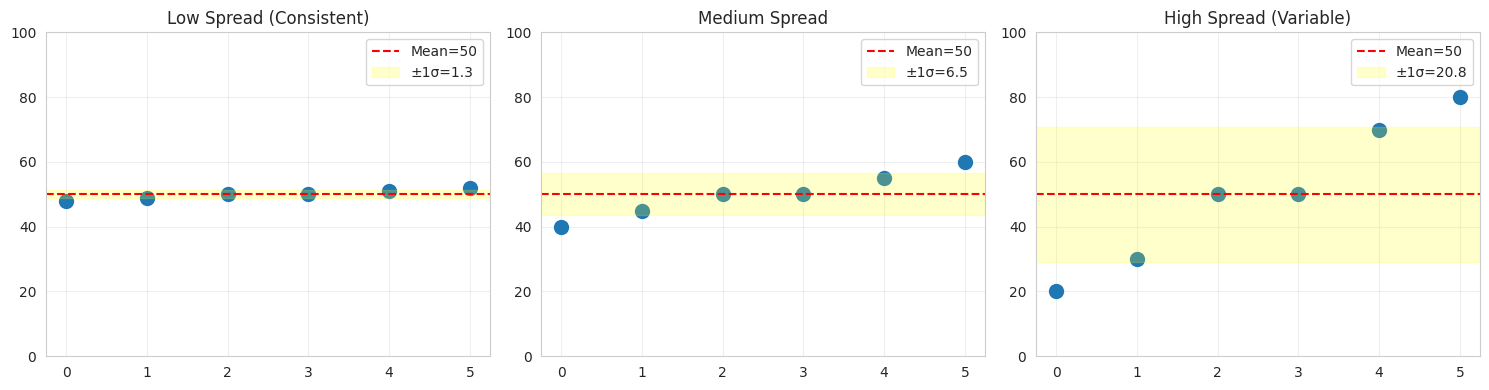


💡 Same mean (50), different spreads!
   Low std  = Consistent/Reliable
   High std = Variable/Unpredictable


In [11]:
# Three datasets with SAME mean, DIFFERENT spreads
low_spread = np.array([48, 49, 50, 50, 51, 52])
med_spread = np.array([40, 45, 50, 50, 55, 60])
high_spread = np.array([20, 30, 50, 50, 70, 80])

datasets = [low_spread, med_spread, high_spread]
labels = ['Low Spread (Consistent)', 'Medium Spread', 'High Spread (Variable)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, label in zip(axes, datasets, labels):
    mean = np.mean(data)
    std = np.std(data)
    
    ax.scatter(range(len(data)), data, s=100)
    ax.axhline(mean, color='red', linestyle='--', label=f'Mean={mean:.0f}')
    ax.axhspan(mean-std, mean+std, alpha=0.2, color='yellow', label=f'±1σ={std:.1f}')
    ax.set_ylim(0, 100)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Same mean (50), different spreads!")
print("   Low std  = Consistent/Reliable")
print("   High std = Variable/Unpredictable")

## 3. Percentiles and IQR

Quartiles:
  Q1 (25th percentile): 58.75
  Q2 (50th percentile/median): 72.5
  Q3 (75th percentile): 86.25

IQR (Q3 - Q1): 27.5
  This is the range of the middle 50% of data

Outlier detection (1.5×IQR rule):
  Values < 17.5 or > 127.5 are outliers


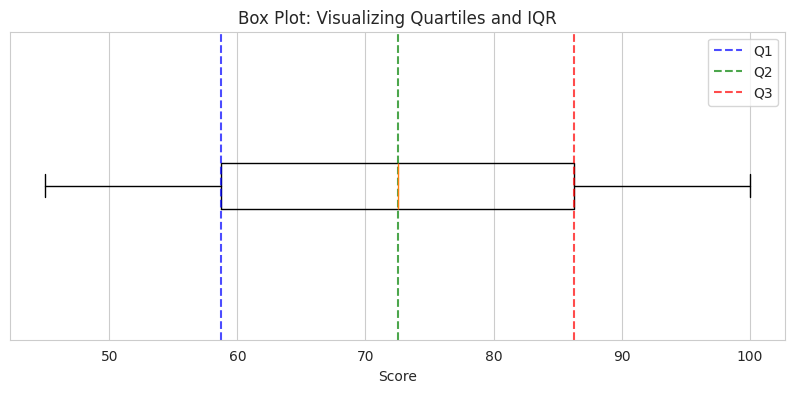

In [12]:
scores = np.array([45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

Q1 = np.percentile(scores, 25)
Q2 = np.percentile(scores, 50)  # Median
Q3 = np.percentile(scores, 75)
IQR = Q3 - Q1

print("Quartiles:")
print(f"  Q1 (25th percentile): {Q1}")
print(f"  Q2 (50th percentile/median): {Q2}")
print(f"  Q3 (75th percentile): {Q3}")
print(f"\nIQR (Q3 - Q1): {IQR}")
print(f"  This is the range of the middle 50% of data")

# Outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nOutlier detection (1.5×IQR rule):")
print(f"  Values < {lower_bound} or > {upper_bound} are outliers")

# Visualize
plt.figure(figsize=(10, 4))
plt.boxplot(scores, vert=False)
plt.axvline(Q1, color='blue', linestyle='--', alpha=0.7, label='Q1')
plt.axvline(Q2, color='green', linestyle='--', alpha=0.7, label='Q2')
plt.axvline(Q3, color='red', linestyle='--', alpha=0.7, label='Q3')
plt.xlabel('Score')
plt.title('Box Plot: Visualizing Quartiles and IQR')
plt.legend()
plt.yticks([])
plt.show()

## 4. Distributions and Skewness

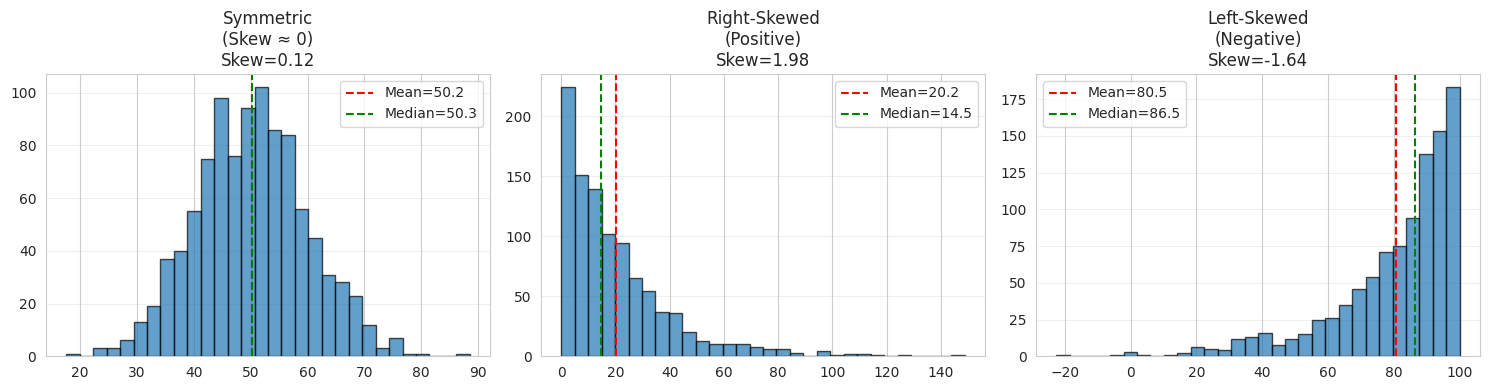


📊 Skewness Guide:
  Skew = 0:  Symmetric (Mean ≈ Median)
  Skew > 0:  Right-skewed (Mean > Median)
  Skew < 0:  Left-skewed (Mean < Median)


In [13]:
# Generate different distributions
np.random.seed(42)

symmetric = np.random.normal(50, 10, 1000)
right_skewed = np.random.exponential(20, 1000)
left_skewed = 100 - np.random.exponential(20, 1000)

from scipy.stats import skew

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in zip(axes, 
                            [symmetric, right_skewed, left_skewed],
                            ['Symmetric\n(Skew ≈ 0)', 'Right-Skewed\n(Positive)', 'Left-Skewed\n(Negative)']):
    mean = np.mean(data)
    median = np.median(data)
    skewness = skew(data)
    
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mean, color='red', linestyle='--', label=f'Mean={mean:.1f}')
    ax.axvline(median, color='green', linestyle='--', label=f'Median={median:.1f}')
    ax.set_title(f'{title}\nSkew={skewness:.2f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Skewness Guide:")
print("  Skew = 0:  Symmetric (Mean ≈ Median)")
print("  Skew > 0:  Right-skewed (Mean > Median)")
print("  Skew < 0:  Left-skewed (Mean < Median)")

## 5. Correlation

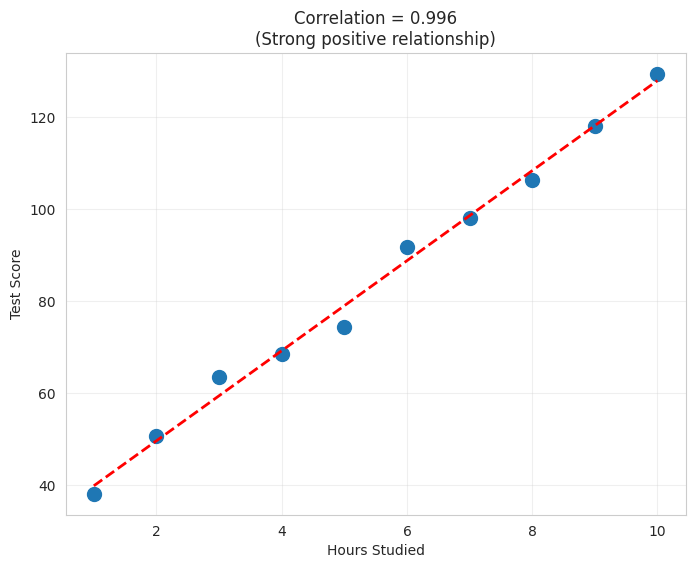

📊 Correlation Scale:
  +1.0:  Perfect positive
  +0.7 to +1.0:  Strong positive
  +0.3 to +0.7:  Moderate positive
   0.0:  No linear relationship
  -0.3 to  0.0:  Weak negative
  -1.0 to -0.7:  Strong negative
  -1.0:  Perfect negative


In [14]:
# Create correlated data
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
test_score = hours_studied * 10 + np.random.randn(10) * 3 + 30

correlation = np.corrcoef(hours_studied, test_score)[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(hours_studied, test_score, s=100)
z = np.polyfit(hours_studied, test_score, 1)
p = np.poly1d(z)
plt.plot(hours_studied, p(hours_studied), "r--", linewidth=2)
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.title(f'Correlation = {correlation:.3f}\n(Strong positive relationship)')
plt.grid(True, alpha=0.3)
plt.show()

print("📊 Correlation Scale:")
print("  +1.0:  Perfect positive")
print("  +0.7 to +1.0:  Strong positive")
print("  +0.3 to +0.7:  Moderate positive")
print("   0.0:  No linear relationship")
print("  -0.3 to  0.0:  Weak negative")
print("  -1.0 to -0.7:  Strong negative")
print("  -1.0:  Perfect negative")

## 6. Z-Scores (Standardization)

In [15]:
scores = np.array([55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

mean = np.mean(scores)
std = np.std(scores)

# Calculate z-scores: z = (x - mean) / std
z_scores = (scores - mean) / std

print("Original vs Z-Scores:\n")
print(f"{'Score':<8} {'Z-Score':<10} {'Interpretation'}")
print("-" * 50)

for score, z in zip(scores, z_scores):
    if z < -1:
        interp = "Below average"
    elif z < 0:
        interp = "Slightly below"
    elif z < 1:
        interp = "Slightly above"
    else:
        interp = "Above average"
    print(f"{score:<8} {z:<10.2f} {interp}")

print(f"\n✅ Z-score properties:")
print(f"   Mean of z-scores: {np.mean(z_scores):.10f} (should be 0)")
print(f"   Std of z-scores:  {np.std(z_scores):.2f} (should be 1)")

print(f"\n💡 This IS what StandardScaler does!")

Original vs Z-Scores:

Score    Z-Score    Interpretation
--------------------------------------------------
55       -1.57      Below average
60       -1.22      Below average
65       -0.87      Slightly below
70       -0.52      Slightly below
75       -0.17      Slightly below
80       0.17       Slightly above
85       0.52       Slightly above
90       0.87       Slightly above
95       1.22       Above average
100      1.57       Above average

✅ Z-score properties:
   Mean of z-scores: -0.0000000000 (should be 0)
   Std of z-scores:  1.00 (should be 1)

💡 This IS what StandardScaler does!


## 7. Outlier Detection

IQR Method:
  Bounds: [22.35, 78.70]
  Outliers found: 5

Z-Score Method (|z| > 3):
  Outliers found: 5


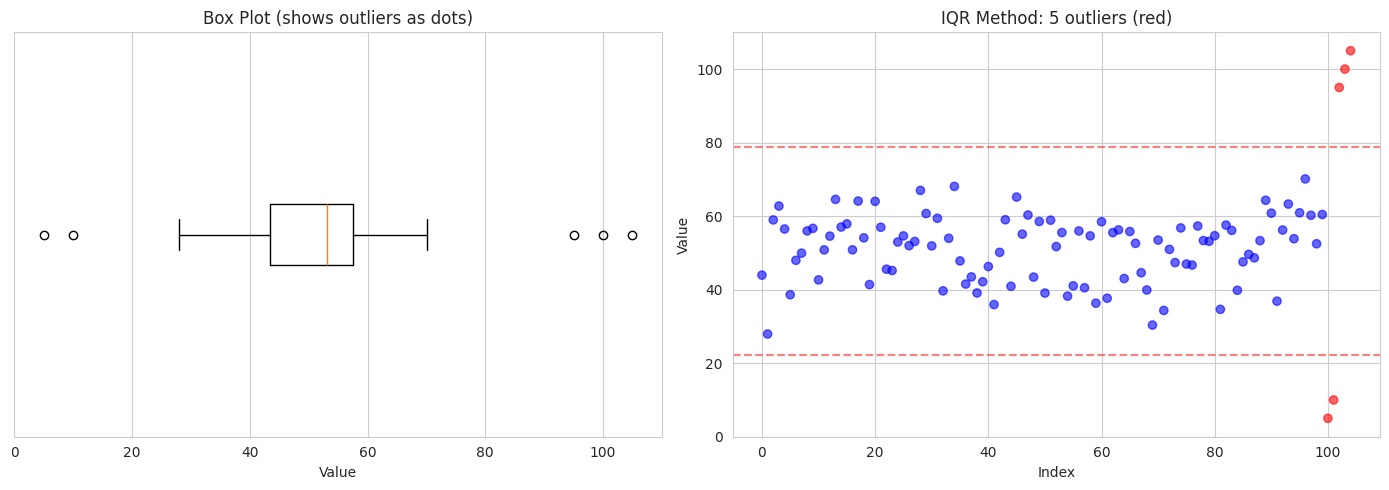

In [16]:
# Create data with outliers
normal_data = np.random.normal(50, 10, 100)
outliers = np.array([5, 10, 95, 100, 105])
data = np.concatenate([normal_data, outliers])

# Method 1: IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = (data < lower) | (data > upper)

# Method 2: Z-score
z_scores = np.abs((data - np.mean(data)) / np.std(data))
outliers_z = z_scores > 3

print("IQR Method:")
print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
print(f"  Outliers found: {np.sum(outliers_iqr)}")

print("\nZ-Score Method (|z| > 3):")
print(f"  Outliers found: {np.sum(outliers_z)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(data, vert=False)
axes[0].set_title('Box Plot (shows outliers as dots)')
axes[0].set_xlabel('Value')
axes[0].set_yticks([])

# Scatter with outliers highlighted
colors = ['red' if o else 'blue' for o in outliers_iqr]
axes[1].scatter(range(len(data)), data, c=colors, alpha=0.6)
axes[1].axhline(lower, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(upper, color='red', linestyle='--', alpha=0.5)
axes[1].set_title(f'IQR Method: {np.sum(outliers_iqr)} outliers (red)')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

## 8. ML Application Example

📊 Dataset Statistics:

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            150.00  
mean               1.20  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  

📈 Correlation Matrix:

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)              1.000            -0.118  

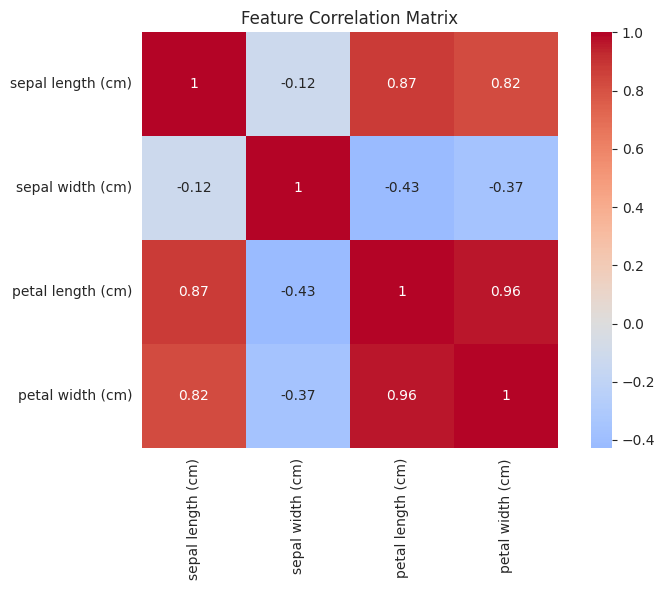

In [17]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("📊 Dataset Statistics:\n")
print(df.describe().round(2))

# Correlation matrix
print("\n📈 Correlation Matrix:\n")
corr = df.corr()
print(corr.round(3))

# Standardize
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df), 
    columns=df.columns
)

print("\n✅ After Standardization:")
print(f"\nMeans (should be ≈0):")
print(df_scaled.mean().round(10))
print(f"\nStds (should be 1):")
print(df_scaled.std().round(2))

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Practice Exercises

### Exercise 1: Calculate All Statistics

In [ ]:
# Given data
data = np.array([12, 15, 18, 20, 22, 25, 28, 30, 35, 100])

# YOUR TASK: Calculate these
# 1. Mean
# 2. Median
# 3. Variance
# 4. Standard deviation
# 5. Q1, Q2, Q3
# 6. IQR
# 7. Which value(s) are outliers using IQR method?

# SOLUTION (uncomment to check):
# print(f"Mean: {np.mean(data):.2f}")
# print(f"Median: {np.median(data):.2f}")
# print(f"Variance: {np.var(data):.2f}")
# print(f"Std Dev: {np.std(data):.2f}")
# print(f"Q1: {np.percentile(data, 25):.2f}")
# print(f"Q2: {np.percentile(data, 50):.2f}")
# print(f"Q3: {np.percentile(data, 75):.2f}")
# Q1, Q3 = np.percentile(data, [25, 75])
# IQR = Q3 - Q1
# print(f"IQR: {IQR:.2f}")
# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR
# print(f"Outlier bounds: [{lower:.2f}, {upper:.2f}]")
# outliers = data[(data < lower) | (data > upper)]
# print(f"Outliers: {outliers}")

### Exercise 2: Mean vs Median Decision

In [ ]:
# Three datasets - which measure should you use?

dataset1 = np.array([10, 12, 13, 14, 15, 16, 17, 18, 20])  # Symmetric
dataset2 = np.array([10, 12, 13, 14, 15, 16, 17, 18, 100])  # Has outlier
dataset3 = np.array([5, 5, 5, 10, 15, 20, 25, 30, 40, 45])  # Right-skewed

# YOUR TASK: For each dataset, decide:
# - Should you use mean or median?
# - Why?

# Calculate both and see the difference!
# SOLUTION (uncomment):
# for i, data in enumerate([dataset1, dataset2, dataset3], 1):
#     print(f"\nDataset {i}:")
#     print(f"  Mean:   {np.mean(data):.2f}")
#     print(f"  Median: {np.median(data):.2f}")
#     print(f"  Skew:   {skew(data):.2f}")

### Exercise 3: Correlation Interpretation

In [ ]:
# Given these correlations, interpret them:
# r = 0.95  between house size and price
# r = -0.87 between study hours and errors on test
# r = 0.15  between shoe size and IQ
# r = -0.42 between age of car and resale value

# YOUR TASK: For each, describe:
# 1. Strength (strong/moderate/weak)
# 2. Direction (positive/negative)
# 3. What it means in real terms

### Exercise 4: Z-Score Application

In [ ]:
# Test scores: mean=75, std=10
# Student A scored 95
# Student B scored 60

# YOUR TASK:
# 1. Calculate z-scores for both students
# 2. What percentile are they approximately in?
# 3. Are either scores unusual (|z| > 2)?

# SOLUTION (uncomment):
# mean, std = 75, 10
# z_A = (95 - mean) / std
# z_B = (60 - mean) / std
# print(f"Student A: z = {z_A:.2f}")
# print(f"Student B: z = {z_B:.2f}")
# print(f"\nStudent A is {z_A:.1f} std devs above mean")
# print(f"Student B is {abs(z_B):.1f} std devs below mean")

## Summary Cheat Sheet

```
╔═══════════════════════════════════════════════════════════╗
║          STATISTICS FOR ML - QUICK REFERENCE              ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  CENTRAL TENDENCY:                                        ║
║    Mean   = Sum / Count (use for symmetric data)         ║
║    Median = Middle value (use for skewed/outliers)       ║
║    Mode   = Most frequent (use for categorical)          ║
║                                                           ║
║  SPREAD:                                                  ║
║    Range    = Max - Min                                   ║
║    Variance = Avg squared deviation (σ²)                  ║
║    Std Dev  = √Variance (σ) ⭐ MOST IMPORTANT             ║
║    IQR      = Q3 - Q1 (robust to outliers)               ║
║                                                           ║
║  RELATIONSHIPS:                                           ║
║    Correlation: -1 to +1                                  ║
║      +1 = perfect positive                                ║
║       0 = no linear relationship                          ║
║      -1 = perfect negative                                ║
║                                                           ║
║  STANDARDIZATION:                                         ║
║    Z-score = (x - μ) / σ                                  ║
║    Result: mean=0, std=1                                  ║
║    |z| > 3: potential outlier                             ║
║                                                           ║
║  OUTLIER DETECTION:                                       ║
║    IQR method: [Q1-1.5×IQR, Q3+1.5×IQR]                   ║
║    Z-score: |z| > 3                                       ║
║                                                           ║
║  ML APPLICATIONS:                                         ║
║    • Feature scaling: StandardScaler uses mean & std      ║
║    • Outlier detection: IQR or z-scores                   ║
║    • Feature selection: correlation                       ║
║    • Always visualize first!                              ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝
```

In [20]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1. Sample Data
data = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Red']})

# 2. Initialize the Encoder
# sparse_output=False makes it easier to read as a standard array
ohe = OneHotEncoder(sparse_output=False)

# 3. FIT and TRANSFORM the training data
encoded_data = ohe.fit_transform(data[['Color']])

# Convert back to a DataFrame to see the column names
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out())

print(encoded_df)

   Color_Blue  Color_Green  Color_Red
0         0.0          0.0        1.0
1         1.0          0.0        0.0
2         0.0          1.0        0.0
3         0.0          0.0        1.0
